# Deep EDA: SOP data quality & intra-class difficulty

Goes a bit deeper than in `eda.py` to answer some questions that
directly shape modeling decisions:

1. **Data quality**: are there corrupt, truncated, tiny, or non-RGB images
   across the *entire* 120k-image dataset (not just a sample)?
2. **Intra-class difficulty**: how visually different are photos of the same
   product? (Model-free proxy via perceptual hashing.)
3. **Label integrity**: do near-identical images appear under different
   product ids (silent label noise / leakage)?

This is EDA only. It reuses `load_split` from `eda.py`; no training logic here.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm.auto import tqdm

# Resolve project root whether launched from repo root or notebooks/.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks"))
from eda import load_split  # reuse the split loader

DATA = ROOT / "data" / "Stanford_Online_Products"
OUT = ROOT / "results" / "eda"
OUT.mkdir(parents=True, exist_ok=True)

# We WANT truncated files to raise so the integrity scan can flag them.
ImageFile.LOAD_TRUNCATED_IMAGES = False
print("project root:", ROOT)
print("data exists  :", DATA.exists())

project root: /Users/arya/Desktop/semblance
data exists  : True


/Users/arya/Desktop/semblance/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load both splits

In [2]:
train = load_split(DATA, "Ebay_train.txt")
test = load_split(DATA, "Ebay_test.txt")
full = pd.concat(
    [train.assign(split="train"), test.assign(split="test")], ignore_index=True
)
print(f"{len(full):,} images total")
full.head()

120,053 images total


,image_id,class_id,super_class_id,path,category,split
0,1,1,1,bicycle_final/111085122871_0.JPG,bicycle,train
1,2,1,1,bicycle_final/111085122871_1.JPG,bicycle,train
2,3,1,1,bicycle_final/111085122871_2.JPG,bicycle,train
3,4,1,1,bicycle_final/111085122871_3.JPG,bicycle,train
4,5,1,1,bicycle_final/111085122871_4.JPG,bicycle,train


## Full-dataset integrity & size scan

Open **every** image header. `im.verify()` checks basic file integrity; a second
open reads dimensions and colour mode. Results are cached to
`results/eda/full_meta.csv` so re-runs are instant.

In [3]:
meta_path = OUT / "full_meta.csv"
if meta_path.exists():
    meta = pd.read_csv(meta_path)
    print("loaded cached meta:", len(meta))
else:
    rows = []
    for rel in tqdm(full["path"], desc="scanning images"):
        p = DATA / rel
        rec = {"path": rel, "ok": True, "width": -1, "height": -1, "mode": "", "error": ""}
        try:
            with Image.open(p) as im:
                im.verify()
            with Image.open(p) as im:
                rec["width"], rec["height"], rec["mode"] = im.width, im.height, im.mode
        except Exception as e:  # noqa: BLE001 -- EDA: we want to record any failure
            rec["ok"] = False
            rec["error"] = f"{type(e).__name__}: {e}"
        rows.append(rec)
    scan = pd.DataFrame(rows)
    meta = full[["path", "class_id", "super_class_id", "category", "split"]].merge(scan, on="path")
    meta.to_csv(meta_path, index=False)
    print("scanned & cached:", len(meta))

scanning images: 100%|██████████| 120053/120053 [00:25<00:00, 4783.02it/s]


scanned & cached: 120053


In [4]:
corrupt = meta[~meta["ok"]]
print("corrupt / unreadable images:", len(corrupt))
if len(corrupt):
    display(corrupt[["path", "category", "split", "error"]].head(20))

corrupt / unreadable images: 0


In [5]:
good = meta[meta["ok"]].copy()
good["width"] = good["width"].astype(int)
good["height"] = good["height"].astype(int)
good["aspect"] = good["width"] / good["height"]
good["min_side"] = good[["width", "height"]].min(axis=1)

print("colour modes:\n", good["mode"].value_counts().to_string())
print("\nnon-RGB images :", int((good["mode"] != "RGB").sum()))
print("tiny (<100px)  :", int((good["min_side"] < 100).sum()))
print("very large (>1000px):", int((good[["width", "height"]].max(axis=1) > 1000).sum()))
print("\nsize summary:\n", good[["width", "height", "aspect", "min_side"]].describe().round(2).to_string())

colour modes:
 mode
RGB    119503
L         550

non-RGB images : 550
tiny (<100px)  : 27
very large (>1000px): 685

size summary:
            width     height     aspect   min_side
count  120053.00  120053.00  120053.00  120053.00
mean      397.48     369.65       1.13     337.67
std       138.35     120.42       0.34     114.40
min        53.00      63.00       0.11      53.00
25%       375.00     300.00       0.86     300.00
50%       400.00     396.00       1.07     300.00
75%       400.00     400.00       1.33     383.00
max      5162.00    3600.00       6.35    2528.00


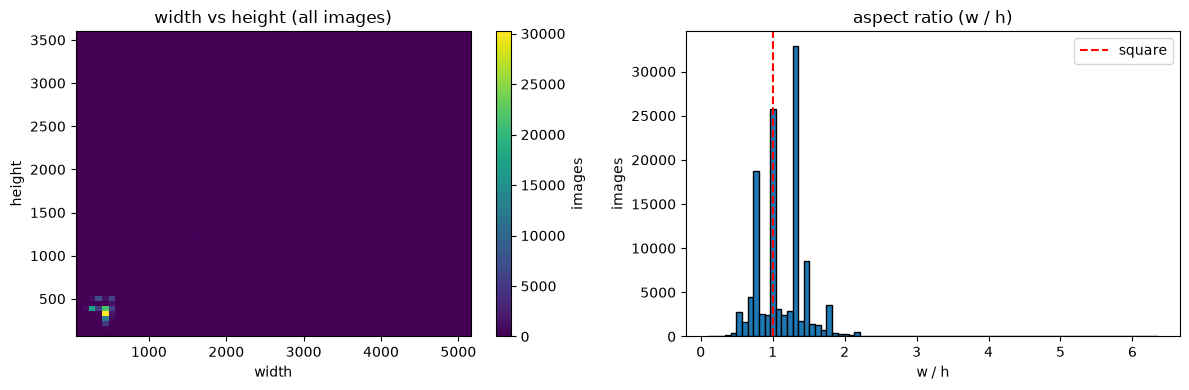

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
h = ax[0].hist2d(good["width"], good["height"], bins=60, cmap="viridis")
fig.colorbar(h[3], ax=ax[0], label="images")
ax[0].set(title="width vs height (all images)", xlabel="width", ylabel="height")
ax[1].hist(good["aspect"], bins=80, edgecolor="black")
ax[1].axvline(1.0, color="r", ls="--", label="square")
ax[1].set(title="aspect ratio (w / h)", xlabel="w / h", ylabel="images")
ax[1].legend()
fig.tight_layout()
fig.savefig(OUT / "full_size_dist.png", dpi=120)
plt.show()

## Intra-class variation — how different are photos of the *same* product?

Without a trained model we use **dHash** (perceptual difference hash) as a
model-free proxy: resize to 9x8 grayscale, compare adjacent pixels -> 64-bit
signature. Hamming distance between two images' hashes approximates visual
dissimilarity (0 = near-identical, ~32 = unrelated).

We compute this for the **300 largest train classes** (bounded work) and rank
classes by mean intra-class Hamming distance: high = "hard positives" the
embedding must pull together despite looking different.

In [7]:
def dhash(path: Path, size: int = 8) -> np.ndarray:
    with Image.open(path) as im:
        small = im.convert("L").resize((size + 1, size), Image.Resampling.LANCZOS)
        arr = np.asarray(small, dtype=np.int16)
    return (arr[:, 1:] > arr[:, :-1]).flatten()


def hamming(a: np.ndarray, b: np.ndarray) -> int:
    return int(np.count_nonzero(a != b))

In [8]:
N_CLASSES = 300  # largest train classes by image count -> bounds the hashing work
sizes = train.groupby("class_id").size().sort_values(ascending=False)
top_classes = sizes.index[:N_CLASSES]
sub = train[train["class_id"].isin(top_classes)].copy()

hashes: dict[str, np.ndarray | None] = {}
for rel in tqdm(sub["path"], desc="hashing"):
    try:
        hashes[rel] = dhash(DATA / rel)
    except Exception:  # noqa: BLE001
        hashes[rel] = None

records = []
for cid, grp in sub.groupby("class_id"):
    hs = [hashes[p] for p in grp["path"] if hashes.get(p) is not None]
    if len(hs) < 2:
        continue
    ds = [hamming(hs[i], hs[j]) for i in range(len(hs)) for j in range(i + 1, len(hs))]
    records.append(
        {"class_id": cid, "n": len(hs), "mean_hd": float(np.mean(ds)),
         "max_hd": int(np.max(ds)), "min_hd": int(np.min(ds))}
    )
var = pd.DataFrame(records).sort_values("mean_hd", ascending=False).reset_index(drop=True)
print("hardest classes (most intra-class variation):")
var.head(10)

hashing: 100%|██████████| 3600/3600 [00:03<00:00, 1169.86it/s]


hardest classes (most intra-class variation):


,class_id,n,mean_hd,max_hd,min_hd
0,8262,12,33.106061,41,25
1,468,12,33.030303,45,24
2,814,12,32.878788,47,19
3,1832,12,32.787879,45,23
4,522,12,32.787879,46,20
5,1223,12,32.772727,52,18
6,8253,12,32.651515,41,19
7,8957,12,32.636364,43,20
8,8795,12,32.545455,43,19
9,1331,12,32.515152,49,19


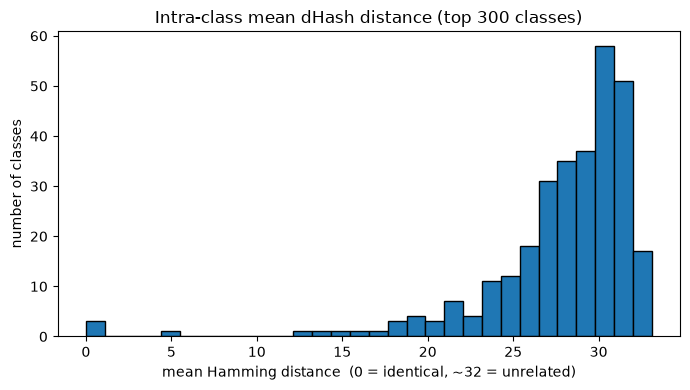

classes with a near-duplicate positive pair (min_hd<=2): 42 / 300


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(var["mean_hd"], bins=30, edgecolor="black")
ax.set(title=f"Intra-class mean dHash distance (top {N_CLASSES} classes)",
       xlabel="mean Hamming distance  (0 = identical, ~32 = unrelated)",
       ylabel="number of classes")
fig.tight_layout()
fig.savefig(OUT / "intra_class_variation.png", dpi=120)
plt.show()

near_dup = int((var["min_hd"] <= 2).sum())
print(f"classes with a near-duplicate positive pair (min_hd<=2): {near_dup} / {len(var)}")

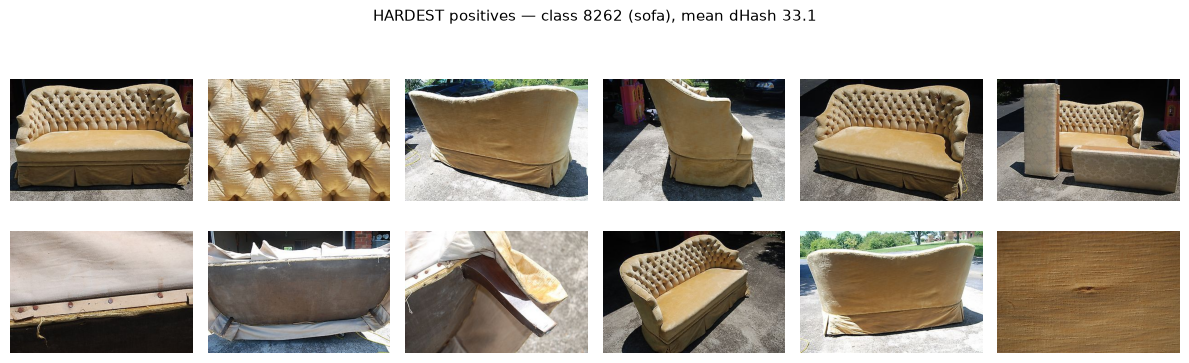

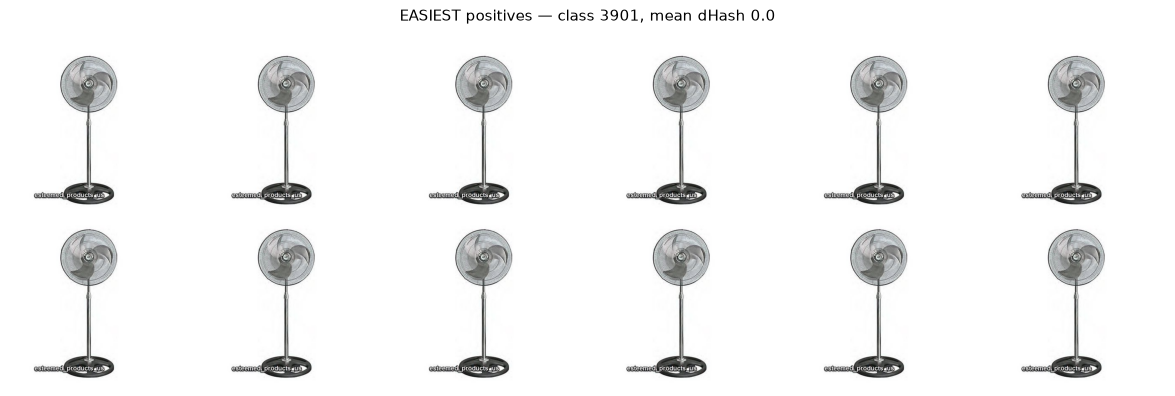

In [10]:
def show_class(cid: int, title: str, k: int = 12) -> None:
    grp = train[train["class_id"] == cid]
    paths = list(grp["path"])[:k]
    cols = min(6, len(paths))
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.atleast_1d(axes).ravel()
    for ax, rel in zip(axes, paths):
        with Image.open(DATA / rel) as im:
            ax.imshow(im.convert("RGB"))
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


hardest = var.iloc[0]
easiest = var.iloc[-1]
hcat = train.loc[train["class_id"] == hardest["class_id"], "category"].iloc[0]
show_class(int(hardest["class_id"]),
           f"HARDEST positives — class {int(hardest['class_id'])} ({hcat}), mean dHash {hardest['mean_hd']:.1f}")
show_class(int(easiest["class_id"]),
           f"EASIEST positives — class {int(easiest['class_id'])}, mean dHash {easiest['mean_hd']:.1f}")

## Cross-product near-duplicates (label-noise / leakage check)

If the same image appears under two different class IDs, that's silent label
noise. Using the hashes already computed, flag identical-hash groups that span
more than one product id. (Limited to the 300 hashed classes since it's a spot check, not
an exhaustive audit.)

In [11]:
p2c = dict(zip(sub["path"], sub["class_id"]))
by_hash: dict[bytes, list[str]] = {}
for rel, h in hashes.items():
    if h is None:
        continue
    by_hash.setdefault(h.tobytes(), []).append(rel)

cross = [ps for ps in by_hash.values() if len({p2c[p] for p in ps}) > 1]
print("identical-hash groups spanning >1 class_id:", len(cross))
for ps in cross[:5]:
    print("  ", [(p, int(p2c[p])) for p in ps])

identical-hash groups spanning >1 class_id: 4
   [('fan_final/141626739745_9.JPG', 3765), ('fan_final/151770397751_7.JPG', 3839), ('fan_final/151777016705_0.JPG', 3846)]
   [('fan_final/151776910696_0.JPG', 3844), ('fan_final/151776910696_8.JPG', 3844), ('fan_final/221382134407_9.JPG', 4088)]
   [('fan_final/151776910696_1.JPG', 3844), ('fan_final/151776964499_9.JPG', 3845)]
   [('fan_final/151776910696_2.JPG', 3844), ('fan_final/151776964499_5.JPG', 3845)]
